In [148]:
import sys
sys.path.append('/home/shuonan.chen/scratch_shuonan/code/LCNE_transcriptomics/code/')
import processing


In [149]:
import numpy as np

In [150]:
np.array((1,-1))

array([ 1, -1])

In [151]:
foo1 = np.arange(0,10).reshape(2,5)
foo2 = foo1*10
foo3 = (10- np.array((1,-1))[:,None]*foo1)
print(foo1)
print(foo2)
print(foo3)


foo1 =foo1+ np.random.random((foo1.shape))
foo2 = foo2+np.random.random((foo1.shape))
foo3 = foo3+np.random.random((foo1.shape))

[[0 1 2 3 4]
 [5 6 7 8 9]]
[[ 0 10 20 30 40]
 [50 60 70 80 90]]
[[10  9  8  7  6]
 [15 16 17 18 19]]


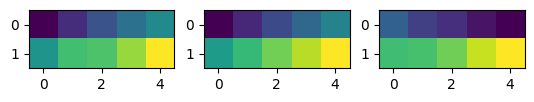

In [152]:
import matplotlib.pyplot as plt 
plt.subplot(1,3,1)
plt.imshow(foo1)
plt.subplot(1,3,2)
plt.imshow(foo2)
plt.subplot(1,3,3)
plt.imshow(foo3)

In [153]:
def func(M):
    from scipy.stats import rankdata
    result = np.apply_along_axis(rankdata, 1, M) 
    means = np.mean(result, axis=1)
    stds = np.std(result, axis=1, ddof=0)
    stds[stds == 0] = 1e-10
    result = (result - means[:,None]) / stds[:,None]
    return result


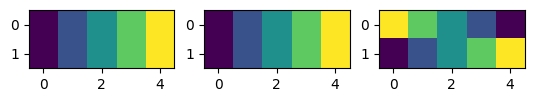

In [154]:
import matplotlib.pyplot as plt 
plt.subplot(1,3,1)
plt.imshow(func(foo1))
plt.subplot(1,3,2)
plt.imshow(func(foo2))
plt.subplot(1,3,3)
plt.imshow(func(foo3))

In [155]:
func(foo3)

array([[ 1.41421356,  0.70710678,  0.        , -0.70710678, -1.41421356],
       [-1.41421356, -0.70710678,  0.        ,  0.70710678,  1.41421356]])

In [156]:
from scipy.stats import rankdata
result = np.apply_along_axis(rankdata, 1, foo2) 
means = np.mean(foo2, axis=0)

In [157]:
foo2

array([[ 0.11469253, 10.6033476 , 20.30796569, 30.42946659, 40.3151515 ],
       [50.07017357, 60.50075875, 70.96359944, 80.61178335, 90.30003187]])

In [158]:
result

array([[1., 2., 3., 4., 5.],
       [1., 2., 3., 4., 5.]])

In [159]:

stds = np.std(result, axis=0, ddof=0)
stds[stds == 0] = 1e-10
result = (result - means) / stds

In [160]:
func(foo2)

array([[-1.41421356, -0.70710678,  0.        ,  0.70710678,  1.41421356],
       [-1.41421356, -0.70710678,  0.        ,  0.70710678,  1.41421356]])

In [161]:
func(foo1)

array([[-1.41421356, -0.70710678,  0.        ,  0.70710678,  1.41421356],
       [-1.41421356, -0.70710678,  0.        ,  0.70710678,  1.41421356]])

In [162]:
from sklearn.neighbors import NearestNeighbors

In [163]:
k = 1
nbrs = NearestNeighbors(n_neighbors=k, metric='euclidean').fit(foo1)
distances, indices = nbrs.kneighbors(foo2) # distance: size (N_mer, K)
print('foo1,foo2\n', distances)

nbrs = NearestNeighbors(n_neighbors=k, metric='euclidean').fit(func(foo1))
distances, indices = nbrs.kneighbors(func(foo2)) # distance: size (N_mer, K)
print('foo1,foo2 (rank)\n', distances)

foo1,foo2
 [[ 40.63823291]
 [143.99021939]]
foo1,foo2 (rank)
 [[0.]
 [0.]]


In [164]:
k = 1
nbrs = NearestNeighbors(n_neighbors=k, metric='euclidean').fit(foo3)
distances, indices = nbrs.kneighbors(foo2) # distance: size (N_mer, K)
print('foo3,foo2\n', distances)

nbrs = NearestNeighbors(n_neighbors=k, metric='euclidean').fit(func(foo3))
distances, indices = nbrs.kneighbors(func(foo2)) # distance: size (N_mer, K)
print('foo3,foo2 (rank)\n', distances)

foo3,foo2
 [[ 29.02344539]
 [121.70280434]]
foo3,foo2 (rank)
 [[0.]
 [0.]]


In [165]:
k = 1
nbrs = NearestNeighbors(n_neighbors=k, metric='euclidean').fit((foo1))
distances, indices = nbrs.kneighbors((foo3)) # distance: size (N_mer, K)
print('foo3,foo1\n', distances)

nbrs = NearestNeighbors(n_neighbors=k, metric='euclidean').fit(func(foo1))
distances, indices = nbrs.kneighbors(func(foo3)) # distance: size (N_mer, K)
print('foo3,foo1 (rank)\n', distances)

foo3,foo1
 [[ 7.08648331]
 [22.82999425]]
foo3,foo1 (rank)
 [[4.47213595]
 [0.        ]]


In [166]:
func(foo1)

array([[-1.41421356, -0.70710678,  0.        ,  0.70710678,  1.41421356],
       [-1.41421356, -0.70710678,  0.        ,  0.70710678,  1.41421356]])

In [167]:
func(foo3)

array([[ 1.41421356,  0.70710678,  0.        , -0.70710678, -1.41421356],
       [-1.41421356, -0.70710678,  0.        ,  0.70710678,  1.41421356]])